# GESTALT 红外超表面演示

本 notebook 展示 GESTALT 的 **IR 超表面（8–14 µm）** 仿真工作流，通过 **juliacall** 桥接调用 Julia 端的 RCWA 求解器。

内容包括：
1. VO₂ 相变材料的实测色散（n, k）
2. 内置形状图案（矩形 / 圆 / 三角 / 十字）
3. 形状 → 反射 / 透射 / 吸收光谱
4. 自定义灰度图 → 光谱
5. **配置驱动通用接口**：任意多层、任意材料的结构化仿真

> 首次运行会启动 Julia 进程并预编译 GESTALT（约几十秒），之后复用同一进程。

## 0. 环境准备

导入 Python API，并准备绘图。默认 `N=4, n_lambda=40` 以便快速演示；
出版级精度可改为 `N=6~8, n_lambda=200`（更慢但更精确）。

In [1]:
import sys, os
# 让 notebook 能导入同目录下的 gestalt_metasurface 模块
sys.path.insert(0, os.path.abspath("."))

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from gestalt_metasurface import (
    run_spectrum, run_shape, shape_image, vo2_dispersion,
    simulate, simulate_from_json, save_result,
)

print("GESTALT 红外超表面 Python API 已加载")
print("可用函数: run_spectrum, run_shape, shape_image, vo2_dispersion, simulate, simulate_from_json, save_result")

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython
GESTALT 红外超表面 Python API 已加载
可用函数: run_spectrum, run_shape, shape_image, vo2_dispersion, simulate, simulate_from_json, save_result


## 1. VO₂ 实测色散

VO₂ 在 ~68 °C 发生绝缘态（monoclinic）→ 金属态（rutile）可逆相变，红外光学性质剧变。
这里使用实测 n,k 表（`data/VO2-I.csv`、`data/VO2-M.csv`）插值得到复折射率。

┌ Warning: attempting to remove probably stale pidfile
│   path = "C:\\Users\\lichu\\.julia\\compiled\\v1.11\\GESTALT\\H65j6_fxxhc.ji.pidfile"
└ @ FileWatching.Pidfile C:\Users\lichu\.julia\juliaup\julia-1.11.9+0.x64.w64.mingw32\share\julia\stdlib\v1.11\FileWatching\src\pidfile.jl:249
[ Info: Precompiling GESTALT [1e0a50c4-4cdb-4753-aaba-50b9c12a7ab8] (cache misses: incompatible header (2))
┌ Warning: attempting to remove probably stale pidfile
│   path = "C:\\Users\\lichu\\.julia\\compiled\\v1.11\\Plots\\ld3vC_JVOvP.ji.pidfile"
└ @ FileWatching.Pidfile C:\Users\lichu\.julia\juliaup\julia-1.11.9+0.x64.w64.mingw32\share\julia\stdlib\v1.11\FileWatching\src\pidfile.jl:249
[ Info: Precompiling JSON3 [0f8b85d8-7281-11e9-16c2-39a750bddbf1] (cache misses: incompatible header (2))


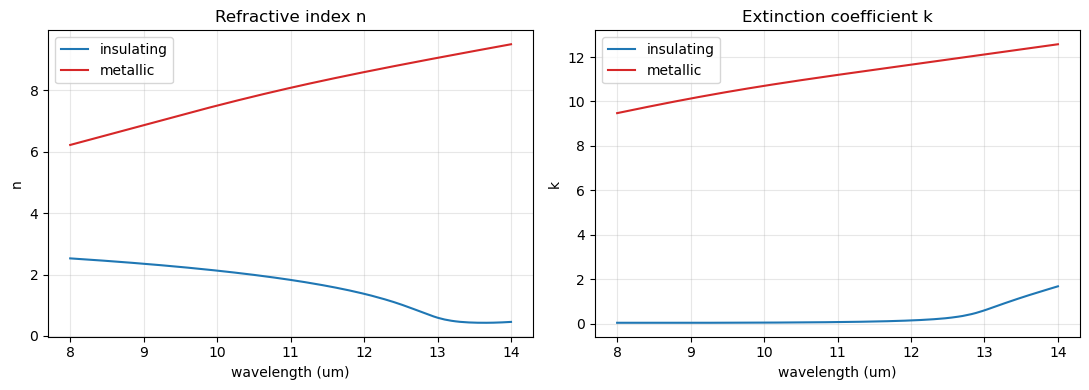

金属态在 LWIR 具有大 n 与大 k（类金属），绝缘态近似透明电介质 —— 相变即光学开关。


In [2]:
phases = ["insulating", "metallic"]
disp = {ph: vo2_dispersion(ph, n_points=200) for ph in phases}

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ph, c in zip(phases, ["tab:blue", "tab:red"]):
    d = disp[ph]
    axes[0].plot(d["wavelength"] * 1e6, d["n"], label=ph, color=c)
    axes[1].plot(d["wavelength"] * 1e6, d["k"], label=ph, color=c)
for ax in axes:
    ax.set_xlabel("wavelength (um)"); ax.legend(); ax.grid(alpha=0.3)
axes[0].set_ylabel("n"); axes[0].set_title("Refractive index n")
axes[1].set_ylabel("k"); axes[1].set_title("Extinction coefficient k")
fig.tight_layout(); plt.show()

print("金属态在 LWIR 具有大 n 与大 k（类金属），绝缘态近似透明电介质 —— 相变即光学开关。")

## 2. 内置形状图案

`shape_image` 生成 64×64 的二值灰度图（0 = 空气，255 = VO₂），作为顶层图案。

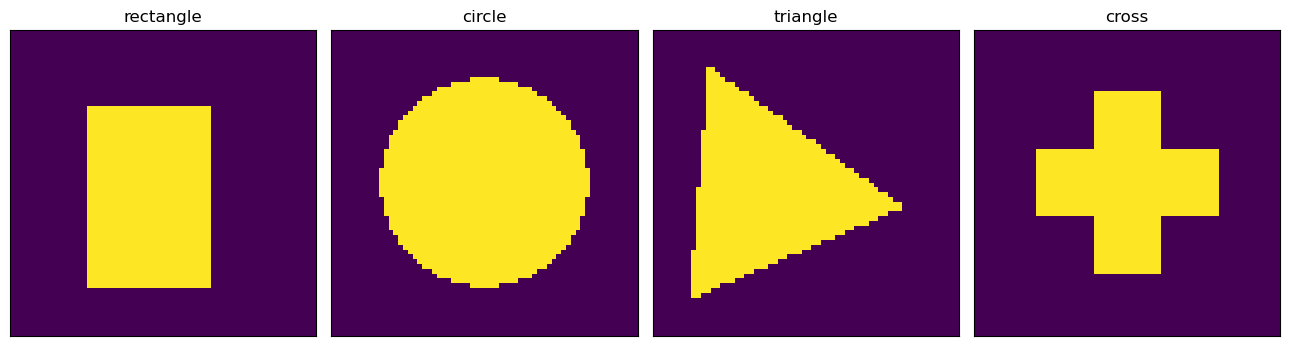

In [3]:
shapes = ["rectangle", "circle", "triangle", "cross"]
fig, axes = plt.subplots(1, 4, figsize=(13, 3.4))
for ax, s in zip(axes, shapes):
    ax.imshow(shape_image(s, N=64), cmap="viridis", origin="lower")
    ax.set_title(s); ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout(); plt.show()

## 3. 形状 → 吸收光谱

圆形图案 + 200 nm 铝镜，对比绝缘态 / 金属态 VO₂ 的吸收谱。
结构：空气 | VO₂ 圆盘(4 µm) | Al(200 nm) | 空气。铝在 LWIR 完全不透明（T≈0），故 A = 1 − R。

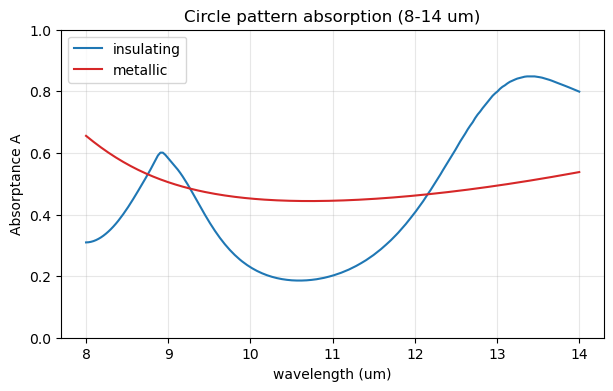

 insulating: A(10 um) = 0.231
   metallic: A(10 um) = 0.452


In [5]:
# N=4, n_lambda=40 快速演示；出版级可用 N=6~8, n_lambda=200
res = {ph: run_shape("circle", ph, N=6, n_lambda=200) for ph in phases}

fig, ax = plt.subplots(figsize=(7, 4))
for ph, c in zip(phases, ["tab:blue", "tab:red"]):
    ax.plot(res[ph]["wavelength"] * 1e6, res[ph]["A"], label=ph, color=c)
ax.set_xlabel("wavelength (um)"); ax.set_ylabel("Absorptance A")
ax.set_title("Circle pattern absorption (8-14 um)")
ax.set_ylim(0, 1); ax.legend(); ax.grid(alpha=0.3)
plt.show()

for ph in phases:
    a10 = res[ph]["A"][np.argmin(abs(res[ph]["wavelength"] - 10e-6))]
    print(f"{ph:>11s}: A(10 um) = {a10:.3f}")

## 4. 自定义灰度图

用任意 `64×64` 灰度矩阵定义图案：0 = 空气，>50 的像素为 VO₂，其厚度 = (灰度/255)×max_t。
这里构造一个中心矩形 VO₂ 柱，并输出 R / T / A 完整光谱。

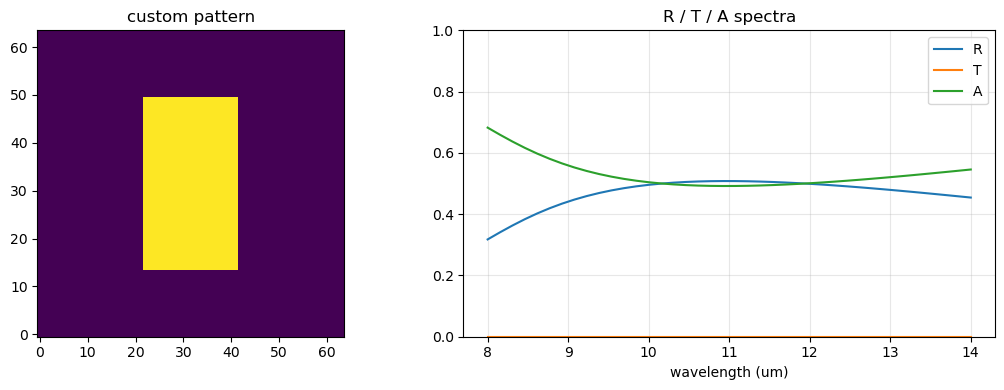

In [6]:
img = np.zeros((64, 64), dtype=np.uint8)
img[14:50, 22:42] = 255          # 中心矩形 VO2 柱

res_custom = run_spectrum(img, "metallic", N=4, n_lambda=40)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].imshow(img, cmap="viridis", origin="lower"); axes[0].set_title("custom pattern")
axes[1].plot(res_custom["wavelength"] * 1e6, res_custom["R"], label="R")
axes[1].plot(res_custom["wavelength"] * 1e6, res_custom["T"], label="T")
axes[1].plot(res_custom["wavelength"] * 1e6, res_custom["A"], label="A")
axes[1].set_xlabel("wavelength (um)"); axes[1].set_ylim(0, 1)
axes[1].set_title("R / T / A spectra"); axes[1].legend(); axes[1].grid(alpha=0.3)
fig.tight_layout(); plt.show()

## 5. 配置驱动通用接口（任意多层）

泛化后的核心接口：**输入一个 JSON/dict 配置，输出结构化结果**，支持任意多层、任意材料、任意波段。
下面构造一个 3 层结构：**空气 | VO₂ 圆盘 | 锗(Ge) 间隔层 | 铝镜 | 空气**，
并同时返回 TE / TM 分偏振吸收谱。

单位约定（SI）：长度/波长/厚度 = 米，角频率 = rad/s，Lorentz 频率 = Hz。

n_harmonics = 81   n_layers = 5
max|R+T+A-1| = 1.1102230246251565e-16 (能量守恒校验)


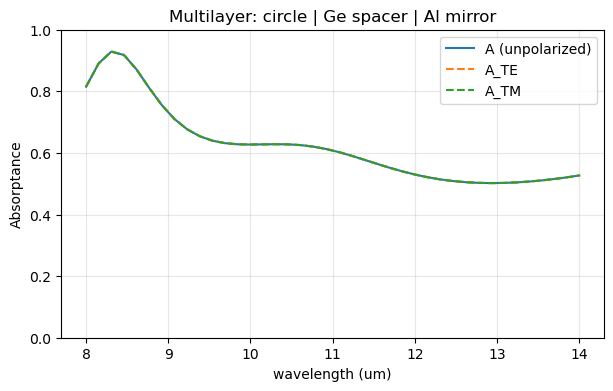

In [7]:
config = {
    "period": 5e-6,
    "N": 4,
    "wavelength": {"min": 8e-6, "max": 14e-6, "n": 40},
    "incidence": {"theta": 0.0, "polarization": "unpolarized"},
    "materials": {
        "air":   {"type": "nk", "n": 1.0, "k": 0.0},
        "vo2_m": {"type": "sampled_nk", "file": "data/VO2-M.csv", "wavelength_unit": "micron"},
        "ge":    {"type": "nk", "n": 4.0, "k": 0.0},
        "al":    {"type": "drude", "omega_p": 2.4e16, "gamma_p": 1.24e14, "eps_inf": 1.0},
    },
    "layers": [
        {"material": "air", "thickness": None},
        {"material": "vo2_m", "pattern": {"type": "shape", "shape": "circle",
                                            "thickness": 4e-6, "background": "air"}},
        {"material": "ge", "thickness": 500e-9},
        {"material": "al", "thickness": 200e-9},
        {"material": "air", "thickness": None},
    ],
}

res_ml = simulate(config)
print("n_harmonics =", res_ml["n_harmonics"], "  n_layers =", res_ml["n_layers"])
print("max|R+T+A-1| =", res_ml["max_abs_RTA_deviation"], "(能量守恒校验)")

wl = res_ml["wavelength_um"]
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(wl, res_ml["A"], label="A (unpolarized)")
ax.plot(wl, res_ml["A_TE"], "--", label="A_TE")
ax.plot(wl, res_ml["A_TM"], "--", label="A_TM")
ax.set_xlabel("wavelength (um)"); ax.set_ylabel("Absorptance")
ax.set_ylim(0, 1); ax.legend(); ax.grid(alpha=0.3)
ax.set_title("Multilayer: circle | Ge spacer | Al mirror")
plt.show()

## 6. 结果落盘（JSON 往返）

结果与配置都可序列化为 JSON 文件，方便与合作者交换、复现实验。

In [8]:
# 结果 dict → JSON 文件
save_result(res_ml, "multilayer_result.json")

# 配置 → JSON 文件 → 重新读取仿真（复现）
import json
with open("multilayer_config.json", "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2)

res_ml2 = simulate_from_json("multilayer_config.json")
print("JSON 往返结果一致:", np.allclose(res_ml["A"], res_ml2["A"]))
print("已生成 multilayer_config.json / multilayer_result.json")

JSON 往返结果一致: True
已生成 multilayer_config.json / multilayer_result.json


## 小结

- **VO₂ 相变**在 LWIR 给出绝缘态（透明）↔ 金属态（高吸收）的可调光学响应；
- **RCWA 求解器**可处理任意灰度图案（单层 / 阶梯多层）与任意多层均匀层；
- **配置驱动接口** `simulate(config)` 把「结构定义」与「求解」解耦，输入输出均为 JSON；
- 多层均匀段已优化为 **2×2 分块对角快速路径**（约 23–29× 加速），能量守恒 `R+T+A=1` 到 ~1e-12。